In [23]:
import torch
# 不同稀有度物品的掉落概率
probs = torch.tensor([0.6, 0.3, 0.09, 0.01])  # 普通, 稀有, 史诗, 传说
drops = torch.multinomial(probs, num_samples=10, replacement=True)
print("本次掉落的物品:", ["普通","稀有","史诗","传说"][drops[0]])

本次掉落的物品: 普通


In [54]:
words = torch.tensor([0.3, 0.25, 0.2, 0.15, 0.1])  # 月亮, 玫瑰, 影子, 梦境, 眼泪
# 使用温度参数控制创造性
temperature = 0.7
scaled_probs = torch.softmax(torch.log(words) / temperature, dim=0)
poem_word = torch.multinomial(scaled_probs, 1).item()
print("", poem_word)

 3


In [92]:
# 用户偏好权重 (电影类型)
user_prefs = torch.tensor([1.2, 0.8, 0.5, 2.0])  # 动作, 喜剧, 爱情, 科幻
# 添加流行度加成
popularity = torch.tensor([0.9, 1.1, 0.8, 1.2])
final_probs = user_prefs * popularity
print("", final_probs)
recommendation = torch.multinomial(final_probs, 3)  # 推荐top3
print("", recommendation)

for w in recommendation:
    print("", w.item())

 tensor([1.0800, 0.8800, 0.4000, 2.4000])
 tensor([0, 1, 3])
 0
 1
 3


C:\Users\Xpeng\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Xpeng\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Xpeng\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31232 (\N{CJK UNIFIED IDEOGRAPH-7A00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Xpeng\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Xpeng\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py

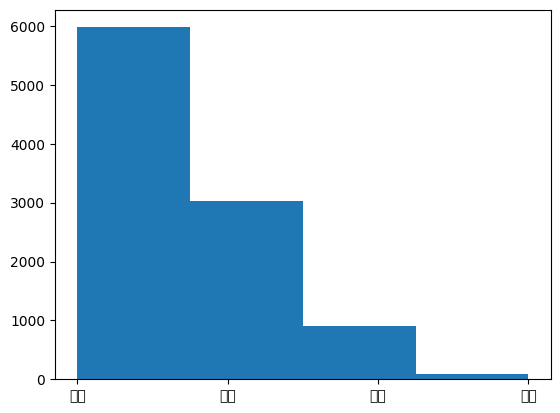

10000
tensor([0, 0, 1,  ..., 1, 1, 0])
类别 0 出现次数: 5979 (59.8%)
类别 1 出现次数: 3028 (30.3%)
类别 2 出现次数: 902 (9.0%)
类别 3 出现次数: 91 (0.9%)


In [102]:
# 可视化采样分布
import matplotlib.pyplot as plt

# 原始代码示例
probs = torch.tensor([0.6, 0.3, 0.09, 0.01])  # 概率分布

samples = torch.multinomial(probs, 10000,replacement=True)
plt.hist(samples.numpy(), bins=len(probs))
plt.xticks(range(4), ['普通','稀有','史诗','传说'])
plt.show()
print(len(samples))
print(samples)

for i in range(len(probs)):
    count = (samples == i).sum().item()
    print(f"类别 {i} 出现次数: {count} ({count/10000:.1%})")
